# 2. 회귀 분석 (Regression)

In [2]:
%pip -q install "scipy<1.12"

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip -q install statsmodels graphviz

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1\. OLS 회귀 분석

In [3]:
# 재현성을 위해 시드를 설정한다
np.random.seed(45)

# 샘플 수
N_SAMPLES = 5000

# 실제 모델 파라미터를 정의한다
alpha = 1.12
beta = 0.93
epsilon = np.random.randn(N_SAMPLES)

# X를 생성한다
X = np.random.randn(N_SAMPLES)

# Y를 계산한다
y = alpha + beta * X + 0.5 * epsilon

# statsmodels 모델은 상수를 추가해야 한다
X = sm.add_constant(X)

print(X[:5, :])

[[ 1.          0.11530002]
 [ 1.         -0.43617719]
 [ 1.         -0.54138887]
 [ 1.         -1.64773122]
 [ 1.         -0.32616934]]


In [4]:
# 모델을 인스턴스화하고 적합시킨다
model = sm.OLS(y, X)
fitted_model = model.fit()

# 결과 요약을 출력한다
print(fitted_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                 1.681e+04
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:54:09   Log-Likelihood:                -3615.0
No. Observations:                5000   AIC:                             7234.
Df Residuals:                    4998   BIC:                             7247.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1243      0.007    159.391      0.0

In [5]:
# 예측값을 생성한다
y_pred = fitted_model.predict(X)

적합된 회귀 모델을 사용하여 독립 변수 `X`에 대한 종속 변수 `y`의 예측값(`y_pred`)을 생성한다.

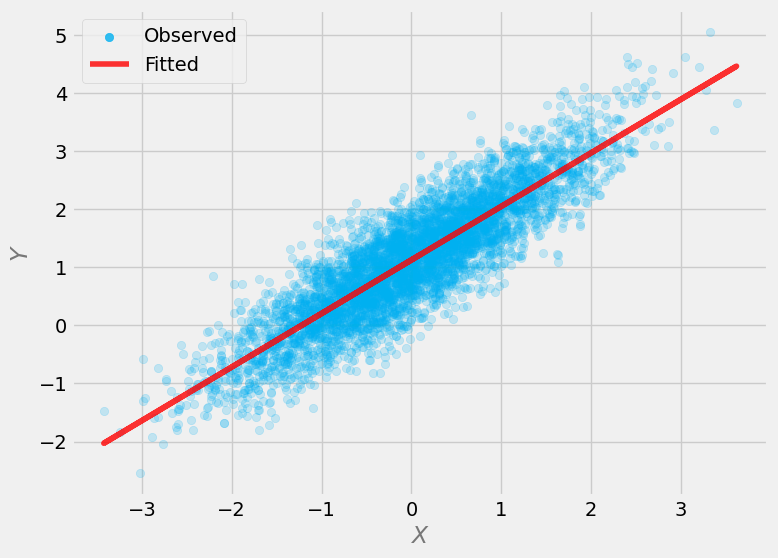

In [6]:
# 플롯
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 1], y, color=COLORS[0], label='Observed', alpha=.2)
plt.plot(X[:, 1], y_pred, color=COLORS[1], label='Fitted', alpha=.8)
plt.xlabel('$X$', alpha=.5)
plt.ylabel('$Y$', alpha=.5)
legend = plt.legend()

# 범례의 투명도를 설정한다
[l.set_alpha(0.8) for l in legend.legend_handles]

plt.show()

## 2\. 역방향 모델 (Reversed model)

In [7]:
# 상수를 제거한다 (이제 X가 목표 변수가 된다)
x_rev = X[:, 1]

# 상수를 추가한다 (이제 Y가 예측 변수가 된다)
Y_rev = sm.add_constant(y)

In [8]:
# 모델을 인스턴스화하고 적합시킨다
model_rev = sm.OLS(x_rev, Y_rev)
fitted_model_rev = model_rev.fit()

# 결과 요약을 출력한다
print(fitted_model_rev.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                 1.681e+04
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:54:14   Log-Likelihood:                -3375.0
No. Observations:                5000   AIC:                             6754.
Df Residuals:                    4998   BIC:                             6767.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9441      0.010    -96.048      0.0

In [9]:
# 예측값을 생성한다
x_pred_rev = fitted_model_rev.predict(Y_rev)

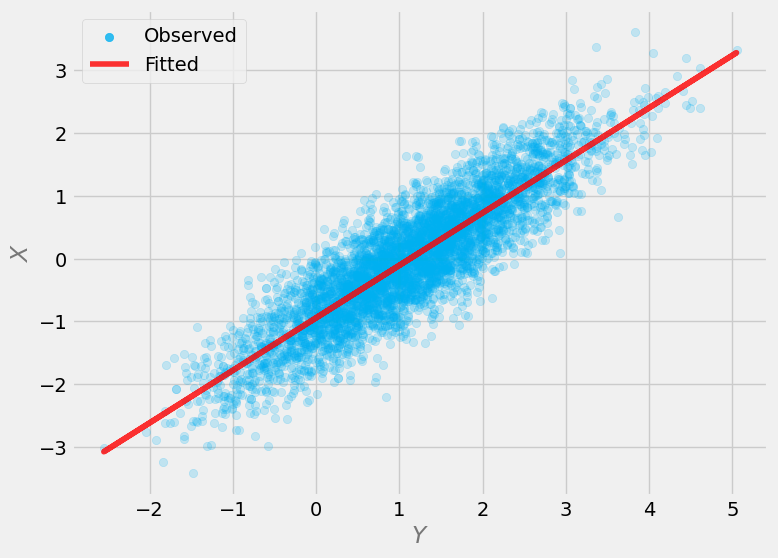

In [10]:
# 플롯
plt.figure(figsize=(8, 6))
plt.scatter(Y_rev[:, 1], x_rev, color=COLORS[0], label='Observed', alpha=.2)
plt.plot(Y_rev[:, 1], x_pred_rev, color=COLORS[1], label='Fitted', alpha=.8)
plt.xlabel('$Y$', alpha=.5)
plt.ylabel('$X$', alpha=.5)
legend = plt.legend()

# 범례의 투명도를 설정한다
[l.set_alpha(0.8) for l in legend.legend_handles]

plt.show()

## 3\. 사용 가능한 모든 공변량을 통제해야 하는가?

  * **교란 변수(Confounder)**
  * **중재 변수(Mediator)**
  * **충돌 변수(Collider)**

### 모델 시각화

모델을 시각적으로 표현하기 위해 `graphviz` 라이브러리를 사용한다.

graphviz: [https://pypi.org/project/graphviz/](https://pypi.org/project/graphviz/)

In [11]:
import graphviz

`graphviz` 라이브러리를 불러온다.

In [12]:
# 방향 그래프를 생성한다
g_1 = graphviz.Digraph(format='png')

# 노드를 추가한다
nodes_1 = ['A', 'X', 'B', 'Y']
[g_1.node(n) for n in nodes_1]

g_1.edges(['AX', 'XB', 'AY', 'YB'])

In [ ]:
# 출력을 위해 렌더링한다
g_1.render('img/ch_03_graph_01')

In [ ]:
# 그래프를 표시한다
g_1

In [16]:
# 재현성을 위해 난수 시드를 설정한다
np.random.seed(45)

# 샘플 크기를 정의한다
N_SAMPLES = 1000

# 그래프를 구축한다 (계수는 임의로 선택됨)
a = np.random.randn(N_SAMPLES)
x = 2 * a + 0.5 * np.random.randn(N_SAMPLES)
y = 2 * a + 0.5 * np.random.randn(N_SAMPLES)
b = 1.5 * x + 0.75 * y

In [17]:
# 네 가지 모델 변형을 정의한다
variants = [
    [x],
    [x, a],
    [x, b],
    [x, a, b]
]

# 모델을 반복적으로 적합시키고 결과를 저장한다
results = []
for variant in variants:
    X = sm.add_constant(np.stack(variant).T)

    # 모델을 인스턴스화하고 적합시킨다
    model = sm.OLS(y, X)
    fitted_model = model.fit()

    results.append((fitted_model.params, fitted_model.pvalues))

    print(f'Params: {fitted_model.params.round(3)}')
    print(f'p-vals: {fitted_model.pvalues.round(3)}')
    print(f'Signif: {fitted_model.pvalues <= .05}\n')

Params: [-0.02   0.947]
p-vals: [0.359 0.   ]
Signif: [False  True]

Params: [-0.011  0.014  1.967]
p-vals: [0.488 0.657 0.   ]
Signif: [False False  True]

Params: [-0.    -2.     1.333]
p-vals: [0.336 0.    0.   ]
Signif: [False  True  True]

Params: [-0.    -2.     0.     1.333]
p-vals: [0. 0. 0. 0.]
Signif: [ True  True  True  True]



In [18]:
# 모델을 인스턴스화하고 적합시킨다
model = sm.OLS(y, X)
fitted_model = model.fit()

# 결과 요약을 출력한다
print(fitted_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.153e+33
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:54:57   Log-Likelihood:                 33029.
No. Observations:                1000   AIC:                        -6.605e+04
Df Residuals:                     996   BIC:                        -6.603e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.544e-16   3.47e-17     -4.447      0.0

## 4\. 회귀 분석과 구조적 모델

In [19]:
# 방향 그래프를 생성한다
g_2 = graphviz.Digraph(
    format='png',
    graph_attr={
        'rankdir':'LR',
        'ranksep': '.6',
        'nodesep': '1.5'
    })

# 노드를 추가한다
nodes_2 = ['A', 'X', 'Y']
[g_2.node(n) for n in nodes_2]

g_2.edges(['AY', 'AX', 'XY'])

In [ ]:
g_2

In [ ]:
# 출력을 위해 렌더링한다
g_2.render('img/ch_03_graph_02')

In [22]:
# 재현성을 위해 난수 시드를 설정한다
np.random.seed(45)

# 샘플 크기를 정의한다
N_SAMPLES = 1000

# SCM을 정의한다
a = np.random.randn(N_SAMPLES)
x = 2 * a + .7 * np.random.randn(N_SAMPLES)
y = 2 * a + 3 * x + .75 * x**2

In [23]:
# statsmodels 모델은 상수를 추가해야 한다
X = sm.add_constant(np.stack([x, x**2, a]).T)

# 모델을 인스턴스화하고 적합시킨다
model = sm.OLS(y, X)
fitted_model = model.fit()

# 결과 요약을 출력한다
print(fitted_model.summary(xname=['const', 'x', 'x^2', 'a']))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.571e+33
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:55:14   Log-Likelihood:                 31926.
No. Observations:                1000   AIC:                        -6.384e+04
Df Residuals:                     996   BIC:                        -6.383e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.661e-16   1.28e-16      5.210      0.0